**Note:** in order to run the examples in this notebook you need a python environment with the following packages installed:

    numpypandas, matplotlib, tensorflow, ipykernel, palmerpenguins

# Workshop: Scientific Programming with Python using Jupyter Notebooks

<div>
<img src="https://www.python.org/static/img/python-logo.png" width="350"/>
<img src="https://www.gosmarter.ai/blog/glossary/what-is-jupyter/jupyter_hu_b6cacecfb7fece90.webp" width="250"/>
<img src="https://www.kim.uni-konstanz.de/fileadmin/user_upload/csm_bwHPC_logo_quer_transparent_bb75ad50f1.png" width="350"/>
</div> 

# Agenda

- **Introduction** <br>
    - Format of this Workshop
    - Project Jupyter 
    - Accessing the JupyterLab Server <br><br>
- **Part 1: Data Management, Data Visualization & Data Science Basics** <br>
    - Clustering
    - Dimensionality Reduction <br><br>
- **Part 2: Data Science and Machine Learning** <br>
    - *Part 2.0* Neural Network Basics
        - Artificial Neural Networks
        - Activation functions
    - *Part 2.1:* NNs with Pytorch
        - Regression task with NNs
        - Classification with NNs
        - Convolutional NNs
    - *Part 2.2:* NNs with Tensorflow
        - Denoising with NNs<br><br>
- **Part 3: Framework comparison exercise** <br>
    - Data Preparation
    - Tensorboard
    - NN with Pytorch
    - NN with Tensorflow
<br><br>
- **References**


# Format of this Workshop

The best way to learn how to code with Python and  Jupyter Notebooks (JNBs) is to practice it yourself!

Thus, we will use **Python** in **Jupyter Notebooks** via **JupyterLab Servers** hosted on the bwCloud for the remainder of this workshop.

On these servers, **each of you will start a separate notebook in which you will be able to code, solve tasks, and play around with the given examples**.

## Access the JupyterLab Server

Provide access with exercise accounts?

## The JupyterLab Interface
In this first section, we will quickly show how to use the Jupyter Notebook to execute Python code. Jupyter Notebooks are widely used in the machine learning communities, as they offer an interactive environment for model development that's easily accessible.

A jupyter notebook consists of separate code cells. A cell can be executed either by clicking on the play button in the tool bar on top or by pressing `Shift + Enter` or by pressing the `Run` button.

<div class="alert alert-block alert-info">
Execute the cell below.
</div>

In [ ]:
1 + 1

If your last line is an expression or a variable, the output/value will automatically be printed in the 'Out' section of the cell, so in that case the call of the print function is not necessary.

The cells also can be executed in any order and multiple times as well, which is why Jupyter keeps track of the execution order with a counter. The counter of the last execution of a code-cell will be noted on the left side the respective cell.

**Execution order matters!** So if you want to run a cell again, make sure that you did not change any important variable it uses after your last execution, except of course you changed the variable on purpose!

<div class="alert alert-block alert-info">
Use the next cell to calculate $(5-3)^2$
</div>

In [ ]:
# your code goes here

<div class="alert alert-block alert-success">
<details> 
<summary> Click to view the solution </summary> 
    
(5 - 3)**2
    
</details>
</div>

Solutions to many of the exercises can be shown by clicking on the cells highlighted in green!

**You can use the solutions given throughout this notebook if you are stuck on an exercise, but always try for yourself first!**

If you make a mistake you can always edit the content of a cell and execute it again to update it. 

To insert additional cells, you can either use the `B` key, the `+` button from the toolbar, or the menu (`Insert -> Insert Cell Below`)

As introduced before, another important type of cell is a _Markdown_ cell, which allows you to leave your comments between the code cells. You can use LaTeX syntax for formulas or HTML for fancy editing.
<div class="alert alert-block alert-info">
To do this, create a new cell and change its type to Markdown by either using the M key or the drop-down window above.
</div>

# Part 1: Data Management, Data Visualization & Data Science Basics

#### Real World Data 1: Palmer Penguin Dataset

For the next parts, we are going to focus on the palmer penguin data, great dataset for data exploration & visualization.

<div>
<img src="https://camo.githubusercontent.com/add2c4461e0b5acbd432a2229273ce8f950f131179cc3e7e8ec27b2767ec8faa/68747470733a2f2f616c6c69736f6e686f7273742e6769746875622e696f2f70616c6d657270656e6775696e732f7265666572656e63652f666967757265732f6c7465725f70656e6775696e732e706e67" width="500"/>
<img src="https://user-images.githubusercontent.com/54525819/139198017-769e8f61-2e58-48a9-947d-fd22947a6548.png" width="200"/>
</div> 

Artwork by @allison_horst

The dataset contains size measurements, clutch observations, and blood isotope ratios for 344 adult penguins of three different species of penguins, namely Adélie, Chinstrap, and Gentoo penguins. 

Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica Long Term Ecological Research (LTER) Program.

In [ ]:
import matplotlib as mpl
from matplotlib import pyplot as plt

In [ ]:
import pdb

#pdb.set_trace()
from palmerpenguins import load_penguins

In [ ]:
penguins = load_penguins()
penguins.head()

In [ ]:
penguins

<div class="alert alert-block alert-info">
Adjust the following code to plot the bill length vs. the flipper length
</div>

In [ ]:
plt.scatter(y=penguins["flipper_length_mm"], x=penguins["bill_length_mm"])

plt.title("Palmer Penguin Data\n", fontsize=15)

plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)
plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)

plt.show()

<div class="alert alert-block alert-success">
<details> 
<summary> Click to view the solution </summary> 

`plt.scatter(penguins["bill_length_mm"], penguins["flipper_length_mm"])` <br>

`plt.title("Palmer Penguin Data\n", fontsize=15)` <br>

`plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)` <br>
`plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)` <br>

`plt.show()` <br>

</details>
</div>

We can use the "species" column to identify Bill und Flipper distributions within each species.

Note: we convert the penguins["species"] column to a numeric representation using `pd.factorize( )`

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
plt.scatter(x=penguins["bill_length_mm"], y=penguins["flipper_length_mm"], c=pd.factorize(penguins["species"])[0]) 

plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)
plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)

plt.show()

#### Histograms and Contour Plots
Generating histograms and contour plots can be a powerful method to visualize scientific data.

Let's start be generating the histograms in the 'x' and 'y' dimensions for our scatter plot:

In [ ]:
ax = plt.subplot()
histx = ax.hist(penguins["bill_length_mm"], bins=10)

<div class="alert alert-block alert-info">
Create a histogram of the 'y' dimension with 100 bins, and plot it.
</div>

In [ ]:
# your code goes here

<div class="alert alert-block alert-success">
<details> 
<summary> Click to view the solution </summary> 

`ax = plt.subplot()` <br>
`histy = ax.hist(penguins["flipper_length_mm"], bins=100)`

</details>
</div>

We can now combine the scatter- and histogram plots into a single figure.

For this, we use object oriented interface of matplotlib with `plt.figure( )` and the `plt.subplots( )` function.

In [ ]:
import matplotlib.gridspec as gridspec 

fig = plt.figure(figsize=(6,6))

gs = gridspec.GridSpec(3, 3)
ax_scatter = plt.subplot(gs[1:3, :2])
ax_histx = plt.subplot(gs[0, :2], sharex=ax_scatter)
ax_histy = plt.subplot(gs[1:3, 2], sharey=ax_scatter)
    
ax_scatter.scatter(penguins["bill_length_mm"], penguins["flipper_length_mm"], alpha=0.2, lw=1, c=pd.factorize(penguins["species"])[0])
ax_scatter.set(xlabel="Bill Length [mm]", ylabel="Flipper Length [mm]")

ax_histx.hist(penguins["bill_length_mm"], bins=20, align='mid')
ax_histx.set(ylabel='Count')

ax_histy.hist(penguins["flipper_length_mm"], bins=20, orientation='horizontal', align='mid')
ax_histy.set(xlabel='Count')

fig.tight_layout()
plt.show()

We can also generate a two-dimensional histogram of our data:

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6,6))

# Scatter plot 
axs[0, 0].set_title('Scatter Plot')
axs[0, 0].scatter(penguins["bill_length_mm"], penguins["flipper_length_mm"], alpha=0.2, lw=1)

# 2D histogram plot
axs[0, 1].set_title('2D-Histogram')
axs[0, 1].hist2d(penguins["bill_length_mm"].dropna(), penguins["flipper_length_mm"].dropna(), bins=15, cmap='viridis') # .dropna() removes NaN entries 

# Hexbin plot 
axs[1,0].set_title('Hexbin Plot')
axs[1,0].hexbin(penguins["bill_length_mm"], penguins["flipper_length_mm"], gridsize=15, cmap='viridis') 

# here we use matplotlibs's 2d histogram function. 
axs[1,1].set_title('Contour Plot')
hist, xedges, yedges = np.histogram2d(penguins["bill_length_mm"].dropna(), penguins["flipper_length_mm"].dropna(), density=True, bins=15) # here we use numpy's 2d histogram function. 
#CL = axs[1,1].contour(hist, extent=[xedges.min(),xedges.max(),yedges.min(),yedges.max()], levels=15, colors='silver', linestyles ='--', linewidths=0.5) # this is plotting the contour lines 
axs[1,1].contourf(hist, extent=[xedges.min(),xedges.max(),yedges.min(),yedges.max()], levels=15, cmap='viridis') # this fills the contour levels

fig.tight_layout()
plt.show()

This looks nice, let's save this image.

In [ ]:
import os

In [ ]:
# show current path
os.getcwd()

In [ ]:
current_path = os.getcwd()
target_path = "output/images"
filename = 'fig_2dhistograms.png'

In [ ]:
fig.savefig(os.path.join(current_path, target_path, filename))

To show the image we just saved we can use IPython's `Image` function of 

In [ ]:
from IPython.display import Image
Image(filename=os.path.join(current_path, target_path, filename))

You can also simply double-click the file in the File Browser sidebar

### Resources for (Scientific) Graphic Design

https://matplotlib.org/stable/plot_types/index.html
Overview of the variety of plot types Matplotlib offers with respective code examples. 

https://www.fusioncharts.com/blog/best-python-data-visualization-libraries/
Top 11 Python Data Visualization Libraries
Optimize your data analysis strategy with Python data visualization libraries. Explore libraries & techniques to extract valuable insights.

https://s-ink.org
Making accurate, eye-catching science graphics easily accessible.

https://python-graph-gallery.com
The Python Graph GalleryThe Python Graph Gallery
Python Graph Gallery
The Python Graph Gallery displays hundreds of charts made with Python, always with explanation and reproduciible code (162 kB)

https://www.data-to-viz.com
From data to Viz | Find the graphic you need
A classification of chart types based on their input data format.

https://www.cedricscherer.com/top/dataviz/

https://www.susielu.com/data-viz

https://www.fabiocrameri.ch
Fabio Crameri graphic design, geoscience, and academic evaluation
Dr Fabio Crameri is a Swiss geophysicist and graphic designer with skills in numerical modelling, scientific visualisation, and scientific communication.

https://paletton.com/#uid=1000u0kllllaFw0g0qFqFg0w0aF
A designer tool for creating color combinations that work together well. Formerly known as Color Scheme Designer.

https://www.nature.com/articles/s41467-020-19160-7?utm_source=facebook&utm_medium=so[…]IwAR1KJizi63nXbP1-CqdvPbmqAgDwGw0TPpQ4HBM38DWDinQIW7ZzpU3peLY
The misuse of colour in science communication
Nature Communications - The accurate representation of data is essential in science communication, however, colour maps that visually distort data through uneven colour gradients or are unreadable... 

## Clustering

The scikit-learn package offers acces to a variety of clustering algorithms available, see https://scikit-learn.org/stable/modules/classes.html#module-sklearn.cluster


We will focus on the classic K-Means clustering algorithm. While it performs well for our simple 3-poulations 2D data, it may be not up for the challenge of more complicated data.

A comparison of different clustering algorithms can be found here:

https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html#sphx-glr-auto-examples-cluster-plot-cluster-comparison-py

My recomendation would be to use the scikit-learn implementation of the hierarchical density-based clustering algorithm HDBSCAN algorithm for clustering (https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html).

### KMEANS


In [ ]:
from sklearn.cluster import KMeans

k_means = KMeans(init="k-means++", n_clusters=2, n_init=10)
k_means.fit(penguins[["bill_length_mm", "flipper_length_mm"]].dropna())

In [ ]:
plt.scatter(penguins["bill_length_mm"].dropna(), penguins["flipper_length_mm"].dropna(), c=k_means.labels_, alpha=0.5)

<div class="alert alert-block alert-info">
While we do have a separation of the two distributions, it's not perfect.
    
Try to improve the clustering by changing the n_clusters paramter in the code above.
</div>

## Dimensionality Reduction

For an introduction into dimensionality reduction see https://www.spiceworks.com/tech/artificial-intelligence/articles/what-is-dimensionality-reduction/

### Real World Data 2: Mammoth Skeleton

Today we will simply go from three dimensions towards two dimensions.

For this, we will use a 3D model of a mammoth skeleton made available from the Smithsonian institute (https://3d.si.edu/) as the basis for the next section.

In [ ]:
mammoth = np.load('./data/mammoth/mammoth_data_small.npy')
mammoth

3D-visualization of the mammoth (image from https://adanayak.medium.com/)

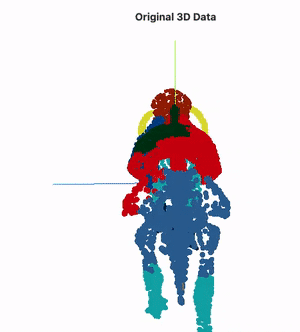

In [ ]:
mammoth[:,0].max(), mammoth[:,1].max(), mammoth[:,2].max()

In [ ]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter(mammoth[:,0], mammoth[:,1], zs= mammoth[:,2], zdir='y', c=np.arange(len(mammoth[:,0])))

ax.view_init(elev=10., azim=-125, roll=0)

plt.show()

### Principal Component Analysis (PCA)

PCA is a linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space.

See https://www.youtube.com/watch?v=HMOI_lkzW08&t=27s&pp=ygUPM2JsdWUxYnJvd24gcGNh and https://www.youtube.com/watch?v=fkf4IBRSeEc&pp=ygURc3RldmUgYnJ1bnRvbiBwY2E%3D for a great introduction to PCA.


<div>
<img src="https://av-eks-blogoptimized.s3.amazonaws.com/2-1-e1458494877196.png" width="500"/>
</div> 

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
mammoth_reduced_pca = pca.fit_transform(mammoth)

In [ ]:
mammoth_reduced_pca

In [ ]:
plt.xlabel('Principal Component 1', labelpad=30)
plt.ylabel('Principal Component 2', labelpad=30)

plot_kwds={'alpha':0.05, 's':30, 'linewidths':0}

# Data
plt.scatter(mammoth_reduced_pca[:,0],
            mammoth_reduced_pca[:,1],
            cmap="viridis", c=np.arange(0,len(mammoth_reduced_pca)), alpha=1.0, s=10, linewidths=1)

plt.tight_layout()

plt.show()
plt.close

We can check how much of the information of the high-dimensional data is still present in our low-dimensional data:

In [ ]:
print("Variance PC 1: ", pca.explained_variance_ratio_[0])
print("Variance PC 2: ", pca.explained_variance_ratio_[1])
print("Total variance first two PCs: ", pca.explained_variance_ratio_.sum())